In [1]:
# load config and embedded AnnData checkpoint
import os
os.chdir("C:/Users/ASRENOVIN/Desktop/spatial-foundation-graph-transformer")

import yaml
import numpy as np
import anndata as ad
import matplotlib.pyplot as plt
from pathlib import Path

with open("configs/default.yaml") as f:
    cfg = yaml.safe_load(f)

adata = ad.read_h5ad("data/processed/adata_embedded.h5ad")

print(adata)
print("\nSpatial coords shape :", adata.obsm["spatial"].shape)
print("Node features shape  :", adata.obsm["X_embedding"].shape)

AnnData object with n_obs × n_vars = 3661 × 20955
    obs: 'in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'hvg', 'log1p', 'pca', 'spatial'
    obsm: 'X_embedding', 'X_pca', 'spatial'
    varm: 'PCs'

Spatial coords shape : (3661, 2)
Node features shape  : (3661, 50)


In [4]:
# build knn graph
from sklearn.neighbors import NearestNeighbors
import scipy.sparse as sp

coords = adata.obsm["spatial"].astype(np.float32)
k = cfg["graph"]["k_neighbors"]

nbrs = NearestNeighbors(n_neighbors = k + 1, metric="euclidean").fit(coords)
distances, indices = nbrs.kneighbors(coords)

# exclude self-loop 
distances = distances[:, 1:]
indices = indices[:, 1:]

n_spots = coords.shape[0]
src = np.repeat(np.arange(n_spots), k)
dst = indices.flatten()
weights = 1.0 / (distances.flatten() + 1e-8)

edge_index = np.stack([src, dst], axis=0)

print("Spots :", n_spots)
print("k neighbors :", k)
print("Total edges :", edge_index.shape[1])
print("Edge weight min/max :", weights.min().round(4), "/", weights.max().round(4))

Spots : 3661
k neighbors : 6
Total edges : 21966
Edge weight min/max : 0.001 / 0.0037


In [5]:
# build adjacency matrix and store in adata
adj = sp.csr_matrix(
    (weights, (src, dst)),
    shape=(n_spots, n_spots)
)

adata.obsp["spatial_connectivities"] = adj
adata.uns["spatial_graph"] = {
    "edge_index"  : edge_index,
    "edge_weights": weights,
    "k_neighbors" : k,
    "method"      : cfg["graph"]["method"],
    "n_edges"     : edge_index.shape[1],
    "n_nodes"     : n_spots,
}

print("Adjacency matrix shape  :", adj.shape)
print("Adjacency matrix nnz    :", adj.nnz)
print("Avg edges per spot      :", adj.nnz / n_spots)
print("Stored in adata.obsp    :", list(adata.obsp.keys()))
print("Stored in adata.uns keys:", list(adata.uns["spatial_graph"].keys()))

Adjacency matrix shape  : (3661, 3661)
Adjacency matrix nnz    : 21966
Avg edges per spot      : 6.0
Stored in adata.obsp    : ['spatial_connectivities']
Stored in adata.uns keys: ['edge_index', 'edge_weights', 'k_neighbors', 'method', 'n_edges', 'n_nodes']


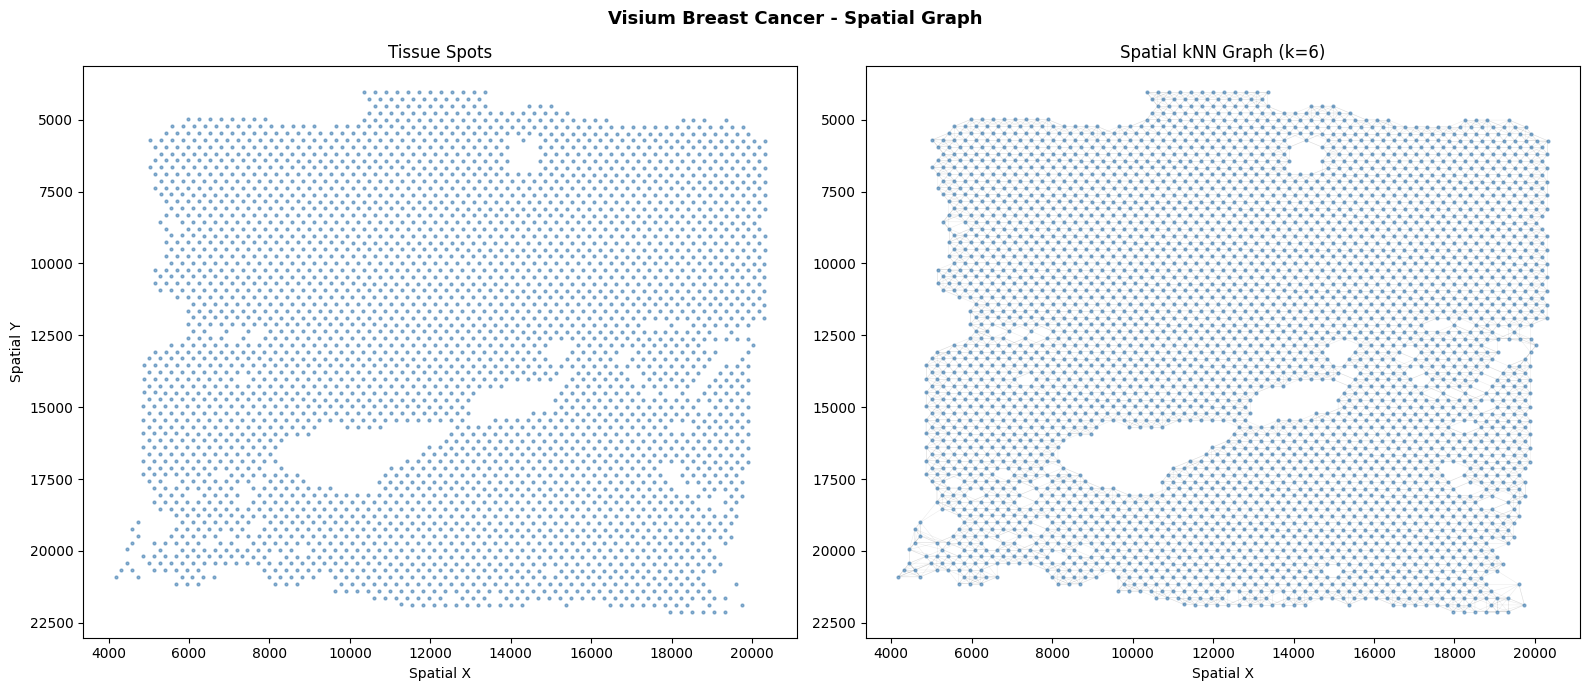

Saved: figures/spatial/spatial_graph.png


In [6]:
# visualize graph (overlay the KNN graph edges on tissue sopt coords)
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# left (spots only)
axes[0].scatter(coords[:, 0], coords[:, 1], s=4, c="steelblue", alpha=0.6)
axes[0].set_title("Tissue Spots")
axes[0].set_xlabel("Spatial X")
axes[0].set_ylabel("Spatial Y")
axes[0].invert_yaxis()

# right (graph overlay)
axes[1].scatter(coords[:, 0], coords[:, 1], s=4, c="steelblue", alpha=0.6, zorder=2)
for i in range(edge_index.shape[1]):
    x0, y0 = coords[edge_index[0, i]]
    x1, y1 = coords[edge_index[1, i]]
    axes[1].plot([x0, x1], [y0, y1], c="gray", alpha=0.15, linewidth=0.4, zorder=1)
axes[1].set_title(f"Spatial kNN Graph (k={k})")
axes[1].set_xlabel("Spatial X")
axes[1].invert_yaxis()

plt.suptitle("Visium Breast Cancer - Spatial Graph", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/spatial/spatial_graph.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: figures/spatial/spatial_graph.png")

In [7]:
# save_graph_and_write_module
adata.write_h5ad("data/processed/adata_graph.h5ad")
print("Saved: data/processed/adata_graph.h5ad")

graph_code = '''from __future__ import annotations
from typing import Any
import numpy as np
import scipy.sparse as sp
import anndata as ad
from sklearn.neighbors import NearestNeighbors


def build_spatial_graph(adata: ad.AnnData, cfg: dict[str, Any]) -> ad.AnnData:
    """
    Build a k-nearest neighbor spatial graph from Visium spot coordinates.

    Stores results in:
        adata.obsp["spatial_connectivities"] - sparse weighted adjacency matrix
        adata.uns["spatial_graph"]           - edge_index, weights, and metadata

    Parameters
    ----------
    adata : AnnData  Embedded AnnData with obsm["spatial"] coordinates.
    cfg   : dict     Master config (uses cfg["graph"]).

    Returns
    -------
    AnnData  Same object with graph stored in obsp and uns.
    """
    coords = adata.obsm["spatial"].astype(np.float32)
    k      = cfg["graph"]["k_neighbors"]
    n_spots = coords.shape[0]

    nbrs = NearestNeighbors(n_neighbors=k + 1, metric="euclidean").fit(coords)
    distances, indices = nbrs.kneighbors(coords)

    distances = distances[:, 1:]
    indices   = indices[:, 1:]

    src     = np.repeat(np.arange(n_spots), k)
    dst     = indices.flatten()
    weights = 1.0 / (distances.flatten() + 1e-8)

    edge_index = np.stack([src, dst], axis=0)

    adj = sp.csr_matrix((weights, (src, dst)), shape=(n_spots, n_spots))

    adata.obsp["spatial_connectivities"] = adj
    adata.uns["spatial_graph"] = {
        "edge_index"  : edge_index,
        "edge_weights": weights,
        "k_neighbors" : k,
        "method"      : cfg["graph"]["method"],
        "n_edges"     : edge_index.shape[1],
        "n_nodes"     : n_spots,
    }

    return adata
'''

with open("src/graphs/spatial_graph.py", "w") as f:
    f.write(graph_code)

print("Created: src/graphs/spatial_graph.py")

Saved: data/processed/adata_graph.h5ad
Created: src/graphs/spatial_graph.py
